# Model Explainability

This notebook explains how the tuned XGBoost model makes fraud predictions.

## Objectives

- Identify the most important features
- Explain global model behaviour
- Explain individual predictions
- Improve transparency using SHAP

In [1]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\praso_smvp0tw\cybershield-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load("../models/xgboost_tuned.pkl")

In [3]:
X_test = joblib.load("../models/X_test_processed.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [4]:
print(type(model))

print(X_test.shape)

print(y_test.shape)

<class 'xgboost.sklearn.XGBClassifier'>
(1817, 6879)
(1817,)


In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test)

In [7]:
print(type(explainer))
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap.explainers._tree.TreeExplainer'>
<class 'shap._explanation.Explanation'>
(1817, 6879)


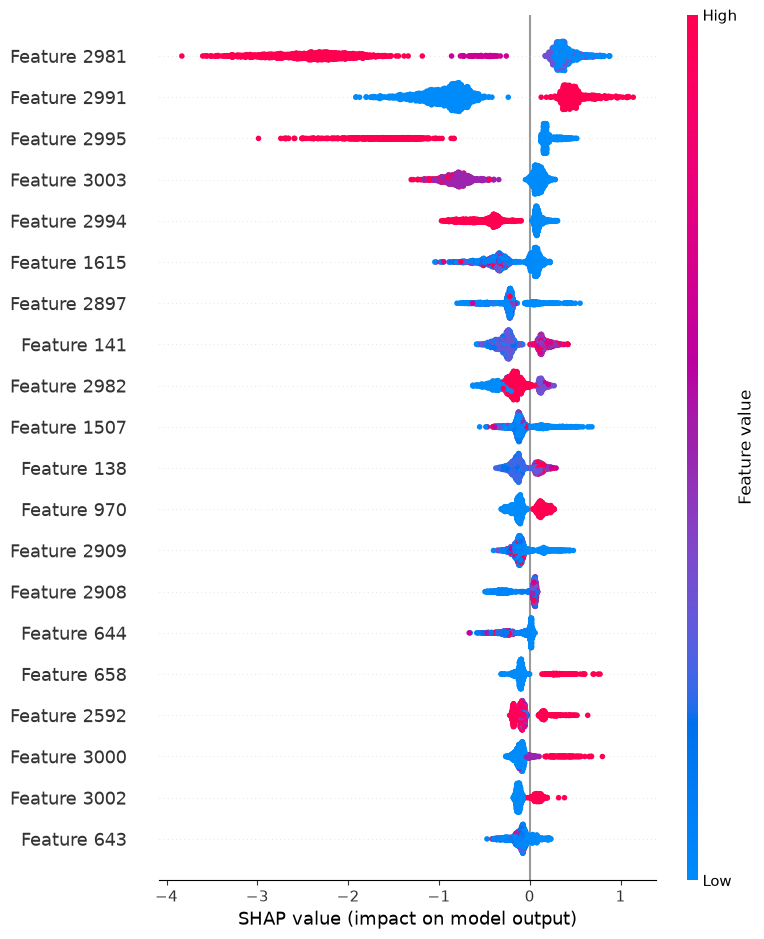

In [8]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=True
)

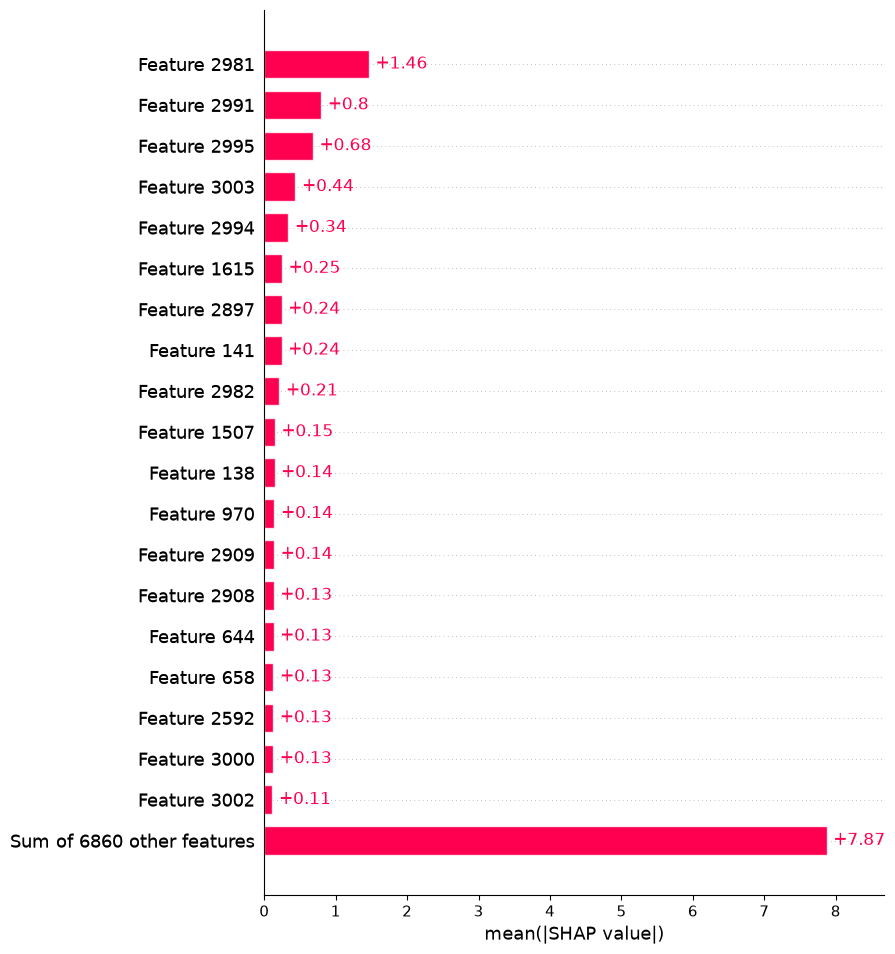

In [9]:
shap.plots.bar(
    shap_values,
    max_display=20
)

In [10]:
fraud_index = np.where(y_test == 1)[0][0]

fraud_index

np.int64(55)

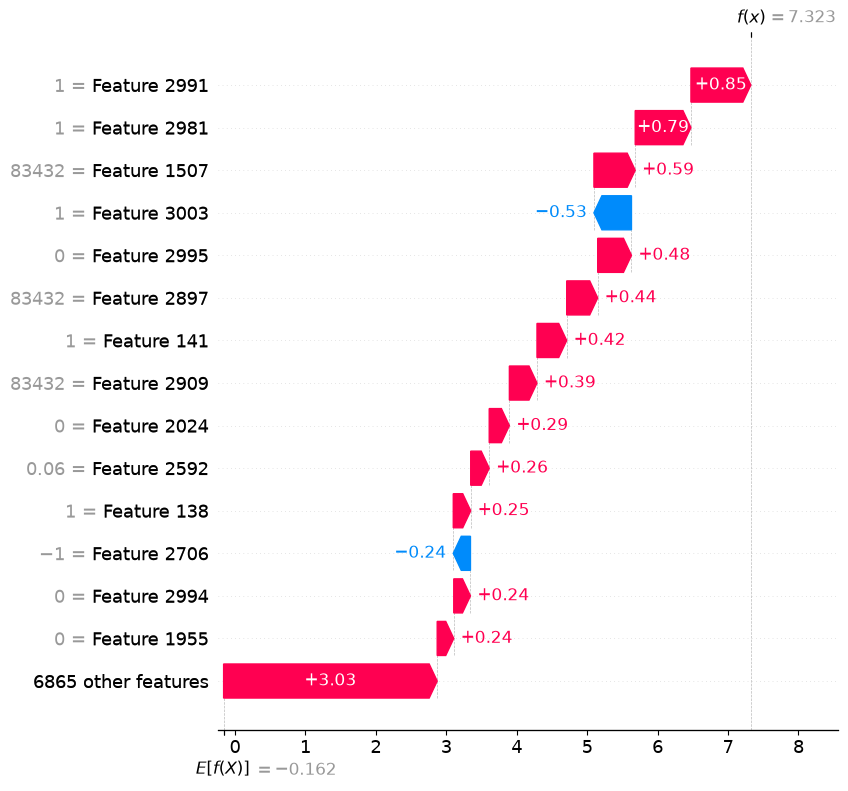

In [12]:
shap.plots.waterfall(
    shap_values[fraud_index],
    max_display=15
)

In [13]:
legit_index = np.where(y_test == 0)[0][0]

legit_index

np.int64(0)

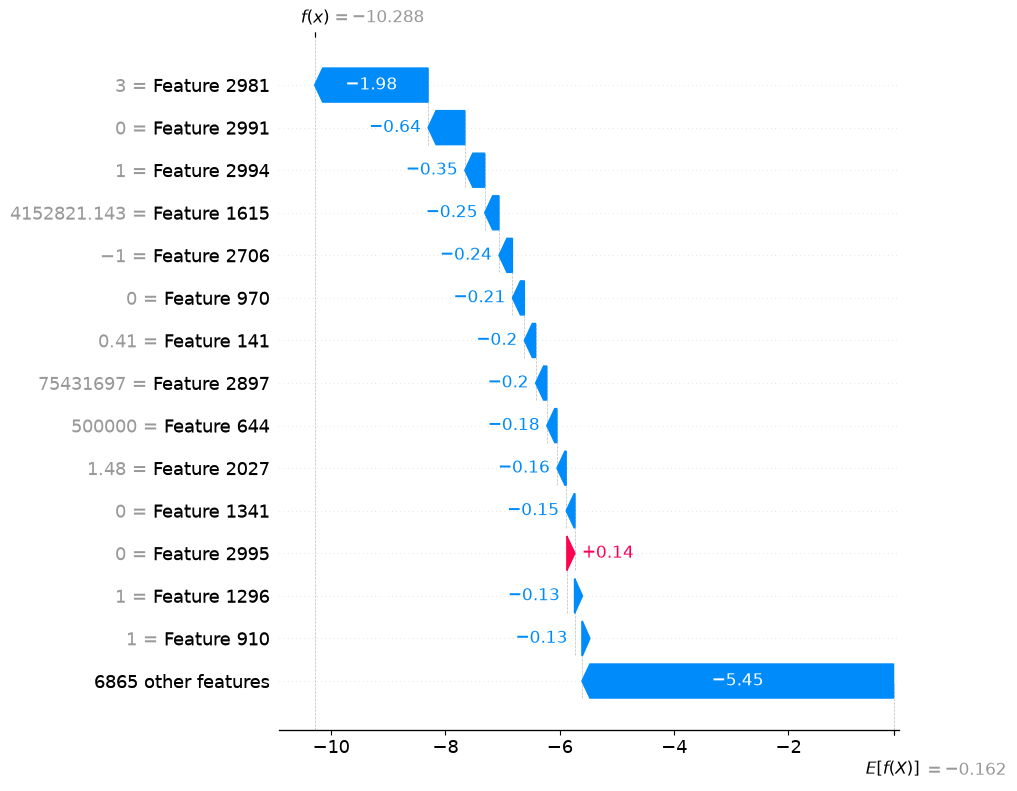

In [14]:
shap.plots.waterfall(
    shap_values[legit_index],
    max_display=15
)

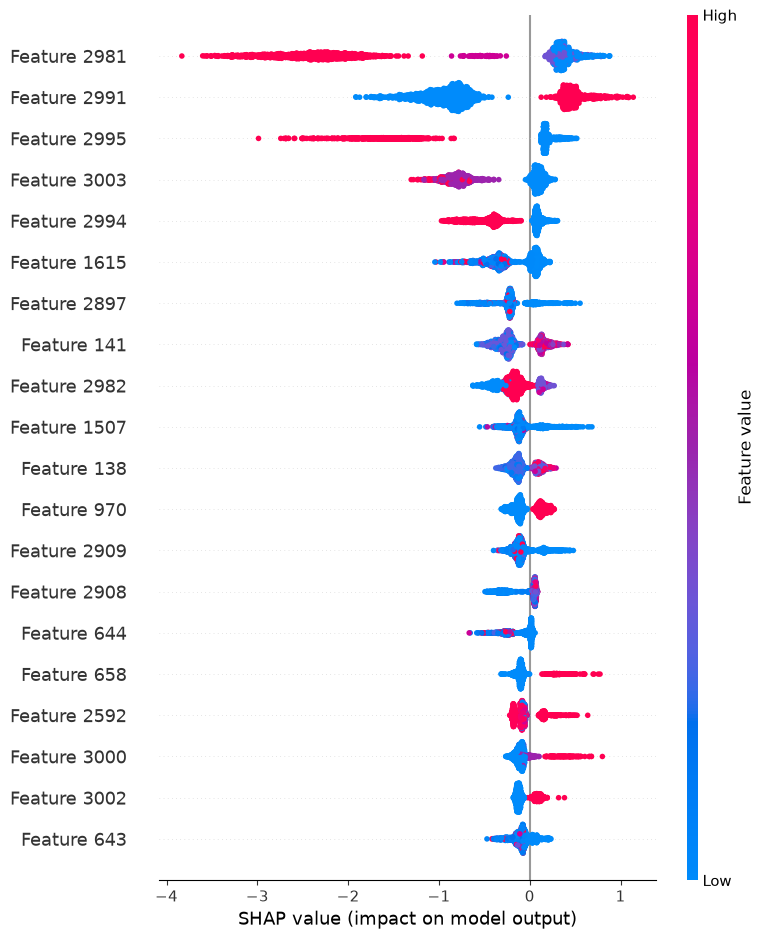

In [15]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP Interpretation

SHAP (SHapley Additive exPlanations) provides both global and local explanations for model predictions.

## Global Interpretation

- The summary plot identifies the most influential features across all transactions.
- Features ranked higher have a greater impact on the model's predictions.
- Feature values (red = high, blue = low) illustrate how different values influence the prediction toward fraud or non-fraud.

## Local Interpretation

The waterfall plots explain individual predictions by showing how each feature contributes to the final model output.

For the selected fraudulent transaction, several important features increased the fraud score, resulting in a fraud prediction.

For the selected legitimate transaction, the dominant feature contributions reduced the fraud score, leading to a legitimate prediction.

These explanations improve model transparency and help analysts understand why specific transactions were flagged.

# Conclusion

The tuned XGBoost model provides excellent predictive performance while remaining interpretable through SHAP explanations.

### Key Outcomes

- Global feature importance was analyzed using SHAP.
- Individual transaction predictions were successfully explained.
- The model provides both high predictive performance and explainability, making it suitable for supporting fraud analysts.

The combination of evaluation metrics, threshold analysis, and explainability demonstrates that the proposed fraud detection pipeline is both accurate and transparent.